# E53 · The Luria-Delbrück fluctuation test: jackpots, a likelihood with no closed form, and Bayesian mutation rates

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: the fluctuation tests of **Luria & Delbrück (1943)**, *E. coli* B cultures tested for resistance to phage T1 - 10 series of parallel cultures (281 cultures, counts of resistant colonies) plus a plating control, TRANSCRIBED from the paper's Tables 1-3 and cross-checked against the R package flan. Sections 1, 3 and 4 also use simulated cultures |
| **You will learn** | The **fluctuation test**: why "induced" resistance gives Poisson counts and **spontaneous** mutation gives heavy-tailed **jackpots** · simulating growing cultures (Yule clones) · the **Luria-Delbrück (Lea-Coulson) distribution** as a compound Poisson: the **Ma-Sandri-Sarkar recursion** written as a **triangular linear solve** in PyTensor so NUTS can sample the mutation rate · **partial plating** (thinning the clone sizes), a **"more than 500"** censored class and binned counts · classic estimators (the 1943 **mean** method, **p0**, Lea-Coulson **median**, **MLE**) against the posterior, and a simulation study of their errors · induced vs spontaneous by **PSIS-LOO** · a **hierarchical** model across experiments and media · **posterior predictive checks of the tail**, and two ways to fatten it: an **induced + spontaneous** mixture and the **Mandelbrot-Koch** differential-growth distribution |

## A Nobel-prize experiment, in one paragraph

In 1943 nobody knew whether bacteria had genes. When a culture of *E. coli* was exposed to a
virus (phage T1), almost every cell died, but a few survivors grew into resistant colonies. Had
the virus **induced** resistance in a few cells it touched, or had resistant **mutants** arisen at
random while the culture grew, before any virus was around? Salvador Luria and Max Delbrück saw
that the two stories predict different **fluctuations** between parallel cultures. If resistance
is induced at the moment of exposure, every cell has the same small chance, and the counts of
survivors in identical cultures scatter like a Poisson variable (variance = mean). If mutations
happen during growth, a mutation that happens early leaves a huge clone of resistant descendants -
a **jackpot** - while most cultures have few or none: the variance is enormous. They found the
jackpots. Bacteria mutate spontaneously and selection only picks out what is already there, the
result for which Luria and Delbrück shared the 1969 Nobel Prize (with Hershey). The same
experiment, the **fluctuation test**, is still how mutation rates are measured today - for
antibiotic resistance, for mutator strains, for cancer cell lines - and its heavy-tailed
distribution is still what makes the estimate hard. This notebook fits it in PyMC.

## The plan

1. Two hypotheses, simulated
2. The 1943 data
3. A likelihood with no closed form: the Luria-Delbrück distribution in PyTensor
4. One experiment, five estimators
5. Induced or spontaneous? All ten experiments
6. One mutation rate? A hierarchical model across experiments and media
7. Is the tail heavy enough? Induced + spontaneous, and fitter mutants
8. Why the tail still matters

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from scipy import linalg, optimize

from pymc_challenges import data

RANDOM_SEED = 53
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · Two hypotheses, simulated

A culture starts from a small inoculum of $N_0$ sensitive cells and grows exponentially to $N_t$
cells. Measure time in units of $1/\text{growth rate}$, so the culture grows as $N_0 e^{s}$ until
$T = \ln(N_t/N_0)$.

- **Spontaneous mutation (Darwinian).** Each cell division produces a resistant daughter with a
  small probability $\mu$ (the **mutation rate per cell per division**). There are
  $N_t - N_0 \approx N_t$ divisions, so the number of mutations in a culture is Poisson with mean
  $m = \mu N_t$. Mutations happen in proportion to the number of cells, so most happen late, but
  a mutation at time $s$ founds a clone that grows for the remaining $T - s$. A clone that
  starts from one cell and grows by random divisions (a Yule process) has a **geometric** size at
  time $T$ with mean $e^{T-s}$. So an early mutation - rare - leaves thousands or millions of
  resistant cells.
- **Induced resistance (Lamarckian).** When the phage is added, each of the $N_t$ cells becomes
  resistant independently with a small probability $a$. The count is Poisson with mean $a N_t$.

We simulate 5,000 cultures of each kind with the scale of Luria and Delbrück's experiment 23
($N_t = 2.4 \times 10^8$ cells, one mutation per culture on average) and give the induced model
the **same mean** count.

spontaneous  mean    9.7  variance       13,499  variance/mean   1,397.8  zeros 0.33  median    1  max 7,109
induced      mean    9.7  variance           10  variance/mean       1.0  zeros 0.00  median    9  max 21


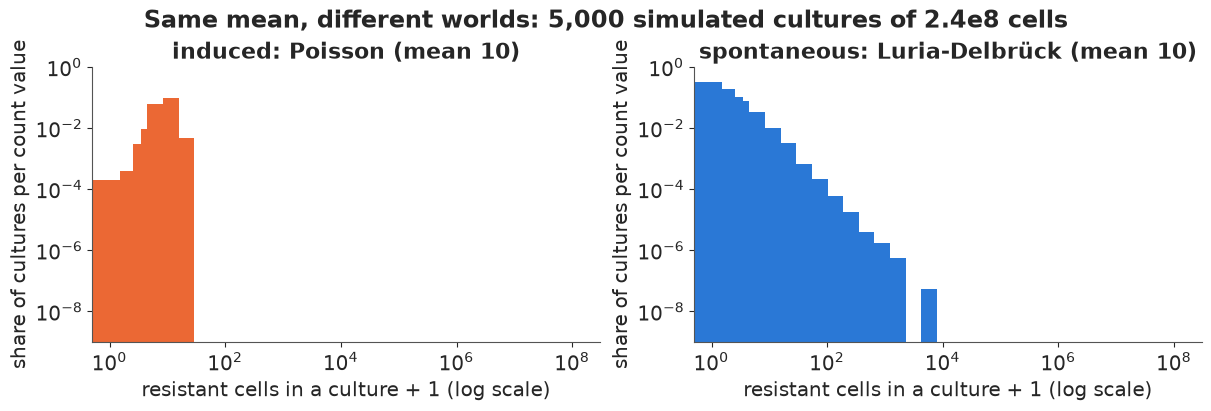

In [2]:
def grow_cultures(mu, n0, nt, n_cultures, rng, fitness=1.0):
    """Resistant cells at the end of growth from n0 to nt cells (spontaneous mutation model).

    Mutations: Poisson(mu * (nt - n0)) per culture, at times with density proportional to the
    population size. A clone founded at time s grows as a Yule process for T - s: its size is
    geometric with success probability exp(-fitness * (T - s)). Clone sizes are capped at nt.
    """
    T = np.log(nt / n0)
    n_mut = rng.poisson(mu * (nt - n0), n_cultures)
    s = np.log1p(rng.uniform(size=n_mut.sum()) * (nt / n0 - 1))     # exponential birth times
    p = np.maximum(np.exp(-fitness * (T - s)), 1.0 / nt)
    clones = rng.geometric(p)
    return np.bincount(np.repeat(np.arange(n_cultures), n_mut), weights=clones,
                       minlength=n_cultures).astype(np.int64)


N_T, N_0, MU_SIM = 2.4e8, 1e3, 1.1 / 2.4e8                          # m = mu * N_t = 1.1
spont = grow_cultures(MU_SIM, N_0, N_T, 5000, rng)
induced = rng.poisson(spont.mean(), 5000)
for name, x in [("spontaneous", spont), ("induced", induced)]:
    print(f"{name:12s} mean {x.mean():6.1f}  variance {x.var():12,.0f}  variance/mean "
          f"{x.var() / x.mean():9,.1f}  zeros {np.mean(x == 0):.2f}  median {np.median(x):4.0f}  "
          f"max {x.max():,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
edges = np.concatenate([[0.5, 1.5, 2.5, 3.5], np.logspace(np.log10(4.5), 8.5, 30)])
for ax, x, c, name in [(axes[0], induced, ORANGE, "induced: Poisson"),
                       (axes[1], spont, BLUE, "spontaneous: Luria-Delbrück")]:
    n_int = np.diff(np.ceil(edges))                   # integers per bin
    h, _ = np.histogram(x + 1, bins=edges)
    ax.stairs(h / len(x) / n_int, edges, fill=True, color=c)
    ax.set(xscale="log", yscale="log", xlim=(0.5, 3e8), ylim=(1e-9, 1),
           xlabel="resistant cells in a culture + 1 (log scale)",
           ylabel="share of cultures per count value", title=f"{name} (mean {x.mean():.0f})")
fig.suptitle("Same mean, different worlds: 5,000 simulated cultures of 2.4e8 cells");

Both sets of cultures have the same average (about 10 resistant cells), but nothing else in
common. Induced resistance gives a tight bell around the mean (variance/mean = 1). Spontaneous
mutation gives a third of cultures with **no** resistant cell (no mutation happened: $e^{-1.1}$),
a median of 1, and a long tail of jackpots from early mutations reaching thousands of
cells - so the variance is more than a thousand times the mean. The sample mean of the spontaneous
cultures is itself dominated by a few jackpots, a warning for estimators based on it (section 4).

## 2 · The 1943 data

Luria and Delbrück ran three kinds of test. **Table 1** is a control: ten samples from **one**
culture, to check that plating itself adds only Poisson noise. **Table 2** has eight series of 5-20
parallel cultures; from each culture one sample (a fraction of the culture: 0.05 of 10 ml, or
0.05-0.08 of 0.2 ml) was spread on a plate covered with phage and the resistant colonies counted.
**Table 3** has two big series (100 and 87 cultures) reported as a frequency table in classes
(0, 1, ..., 6-10, 11-20, ..., 501-1000); in experiment 23 the **whole** culture was plated.

In [3]:
data.describe("luria_delbruck_1943")
ld = data.load("luria_delbruck_1943")
ld["plated"] = ld.sample_ml / ld.culture_ml
print(ld.groupby(["table", "experiment"], sort=False).agg(
    medium=("medium", "first"), cultures=("n_cultures", "sum"), culture_ml=("culture_ml", "first"),
    fraction_plated=("plated", "first"), cells=("cells_per_culture", "first"),
    max_count=("count_hi", "max")).to_string())

luria_delbruck_1943: E. coli B cultures tested for resistance to phage T1 (one row per culture, or per frequency class in table 3). table: 1 = ten samples from ONE culture (plating control), 2 = one sample from each of a series of parallel cultures, 3 = frequency distribution for 100 and 87(88) parallel cultures; experiment; medium (broth or synthetic); culture_ml and sample_ml (the fraction plated is sample_ml / culture_ml); cells_per_culture (bacteria per culture at the time of the test); culture (index); count_lo, count_hi (resistant colonies on the plate: equal for an exact count, a class such as 6-10 in table 3); n_cultures (cultures in that row).
  source: Luria & Delbrueck (1943), Mutations of bacteria from virus sensitivity to virus resistance, Genetics 28:491-511 (PMC1209226), Tables 1-3. TRANSCRIBED from the ESP Foundations reprint at the URL (a PDF, not a CSV) and cross-checked against the dataset `luriadel` of the CRAN package flan (Mazoyer et al.), so keep the cached file 

                  mean     var  max  var/mean
table experiment                             
1     10a         16.7    18.2   26       1.1
      11a         51.4    38.7   65       0.8
      3            3.3     3.3    7       1.0
2     1           26.8  1400.9  125      52.3
      10          24.0   114.6   41       4.8
      11          62.4  3958.7  183      63.4
      15          26.2  2410.2  165      92.0
      16          11.4   752.1  107      66.3
      17          30.6  7542.3  303     246.6
      21a          3.8    43.8   19      11.6
      21b         44.2  1325.7  107      30.0


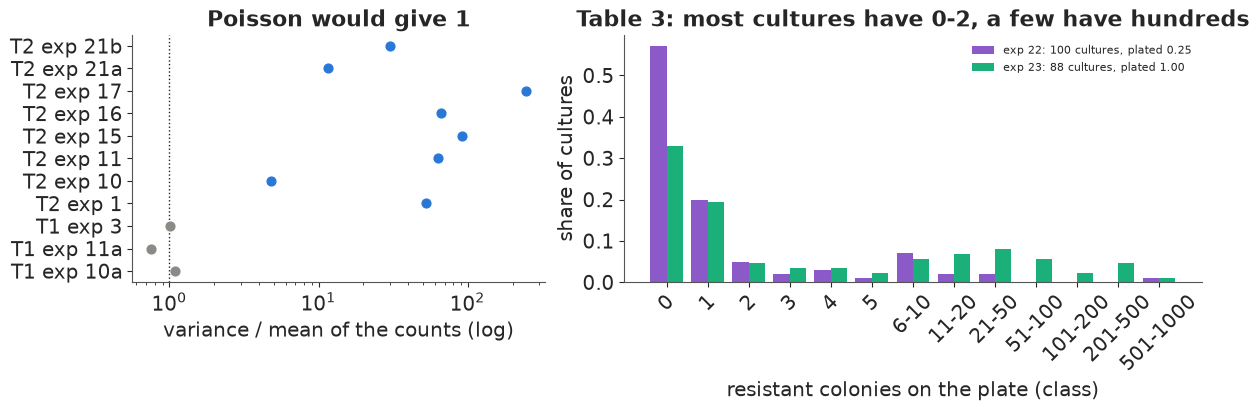

In [4]:
exact = ld[ld.table <= 2]
stats = exact.groupby(["table", "experiment"], sort=False)["count_lo"].agg(["mean", "var", "max"])
stats["var/mean"] = stats["var"] / stats["mean"]
print(stats.round(1).to_string())

tab3 = ld[ld.table == 3]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), width_ratios=[1, 1.4])
ax = axes[0]
for (tab, e), row in stats.iterrows():
    c = GREY if tab == 1 else BLUE
    ax.scatter(row["var/mean"], f"{'T1' if tab == 1 else 'T2'} exp {e}", color=c, s=40, zorder=3)
ax.axvline(1, color=INK, ls=":", lw=1)
ax.set_xscale("log")
ax.set(xlabel="variance / mean of the counts (log)", title="Poisson would give 1")
ax = axes[1]
labels = [f"{lo}" if lo == hi else f"{lo}-{hi}" for lo, hi in
          tab3[tab3.experiment == "22"][["count_lo", "count_hi"]].to_numpy()]
x = np.arange(len(labels))
for k, (e, c) in enumerate([("22", PURPLE), ("23", AQUA)]):
    sub = tab3[tab3.experiment == e]
    ax.bar(x + (k - 0.5) * 0.4, sub.n_cultures / sub.n_cultures.sum(), width=0.4, color=c,
           label=f"exp {e}: {sub.n_cultures.sum()} cultures, plated {sub.plated.iloc[0]:.2f}")
ax.set_xticks(x, labels, rotation=45)
ax.set(xlabel="resistant colonies on the plate (class)", ylabel="share of cultures",
       title="Table 3: most cultures have 0-2, a few have hundreds")
ax.legend(fontsize=8);

Left: in the plating control (Table 1, grey) the variance is about equal to the mean, as it must
be for random samples from one culture. Across parallel cultures (Table 2, blue) the
variance/mean ratio is 5 to 250. That is the whole qualitative argument of the paper: the extra
variance comes from the cultures, not the plating, and it is far too large for induction. Right:
the two big series have the jackpot shape of section 1 - a third to a half of the cultures with no
resistant colony and a few with hundreds.

Two notes on the transcription (details in `data.describe`). In experiment 23 the frequency
classes add up to **88** cultures, while the paper says 87 (with 29 zeros); we keep the 88 rows as
printed. The widest classes (201-500, 501-1000) hide the exact size of the biggest jackpots - a
censoring the likelihood has to respect.

## 3 · A likelihood with no closed form

The spontaneous model is a **compound Poisson** distribution: the number of mutations is
Poisson($m$), and each mutation contributes a clone. Section 1 gives the clone size: geometric with
mean $1/u$, where $u = e^{-(T-s)}$ is the fraction of the final population that existed when the
mutation happened. Because mutations happen in proportion to the population, $u$ is **uniform** on
(0, 1), and averaging the geometric over $u$ gives the clone size distribution

$$P(\text{clone} = k) = \int_0^1 u(1-u)^{k-1}\,du = \frac{1}{k(k+1)}, \qquad k = 1, 2, \dots$$

which has an infinite mean. The number of resistant cells in a culture, the **Luria-Delbrück
distribution** in its Lea-Coulson form, has no closed form, but its probabilities obey a simple
recursion (Ma, Sandri & Sarkar 1992). For any compound Poisson with clone-size probabilities
$h_j$ and $m$ clones on average,

$$p_0 = e^{-m(1-h_0)}, \qquad p_n = \frac{m}{n}\sum_{j=1}^{n} j\,h_j\,p_{n-j}, \quad n \ge 1,$$

and with $h_j = 1/(j(j+1))$ this is the Ma-Sandri-Sarkar formula
$p_n = \frac{m}{n}\sum_{i<n} p_i/(n-i+1)$.

**As a linear solve.** The recursion says $(I - m A)\,p = p_0 e_0$ with a strictly lower
triangular matrix $A_{n,i} = (n-i)\,h_{n-i}/n$. So $p_0,\dots,p_N$ come from **one triangular
solve**, which PyTensor differentiates for us (`pt.linalg.solve_triangular`): no loop, no `scan`,
exact gradients for NUTS, well under a millisecond for a few hundred terms. The probabilities are all positive
and forward substitution only adds positive terms, so it is numerically stable. For very large
$m$ the ratio $p_n/p_0$ overflows, so we solve for a rescaled vector.

**Extensions in the same frame**, each just a different $h_j$:

- **Partial plating.** If a fraction $\varepsilon$ of the culture is plated, each resistant cell
  lands on the plate with probability $\varepsilon$: the clone sizes are **thinned**, which a
  geometric survives in closed form, so $h_j(\varepsilon)$ is a one-dimensional integral over $u$
  (done once, by quadrature, in NumPy). Now $h_0 > 0$: a clone can miss the plate entirely.
  Luria and Delbrück plated as little as $\varepsilon = 0.005$.
- **Induced resistance on top** adds Poisson($\lambda$) single cells: $m h_1 \to m h_1 + \lambda$.
- **Mutants that grow at a different rate** (relative fitness $w$; Mandelbrot 1974, Koch 1982):
  the clone founded at $u$ is geometric with mean $u^{-w}$; with $\rho = 1/w$ the mixing density
  becomes $\rho\,u^{\rho-1}$ and $h_j(\rho) = \rho\,B(j, \rho+1)$ (the Yule-Simon distribution).
  This one depends on a parameter, so the quadrature runs inside the model.

Binned classes enter as $\log \sum_{n \in \text{class}} p_n$. The cost of the solve grows as
$N^2$, so we stop the vector at $N = 200$: counts above 200 (only in experiments 22 and 23: the
classes 201-500 and 501-1000, six cultures) enter as "more than 200",
$\log(1 - \sum_{n \le 200} p_n)$. That throws away a little information about the very largest
jackpots and keeps each fit to well under a minute; the predictive checks below use the original
classes.

In [5]:
CAP = 200
_t, _w = np.polynomial.legendre.leggauss(400)                  # Gauss-Legendre in log(u)
LOG_U_MIN = -32.0
U = np.exp(0.5 * (_t + 1) * (-LOG_U_MIN) + LOG_U_MIN)
W_U = _w * 0.5 * (-LOG_U_MIN) * U                             # du = u d(log u)


def clone_matrix(eps, N):
    """C[j, q] @ density(u_q) = P(j cells of a clone are plated), j = 0..N.

    A clone with parameter u is geometric on 1, 2, ... with success probability u; thinning each
    cell with probability eps gives P(0) = (1-eps) u/c and P(j) = u/c r^(j-1) ((1-eps) r + eps),
    with c = 1 - (1-u)(1-eps) and r = (1-u) eps / c.
    """
    x = 1 - U
    c = 1 - x * (1 - eps)
    r = x * eps / c
    j = np.arange(1, N + 1)[:, None]
    return np.vstack([(U / c) * (1 - eps), (U / c) * r ** (j - 1) * ((1 - eps) * r + eps)]) * W_U


class Fluctuation:
    """One series of parallel cultures: data, plating fraction, and its likelihood pieces."""

    def __init__(self, rows, cap=CAP):
        rows = rows.loc[rows.index.repeat(rows.n_cultures)]              # one row per culture
        self.name = rows.experiment.iloc[0]
        self.eps = float(rows.plated.iloc[0])
        self.cells = float(rows.cells_per_culture.iloc[0])
        self.synthetic = rows.medium.iloc[0] == "synthetic"
        self.lo = rows.count_lo.to_numpy()
        self.hi = np.where(rows.count_hi > cap, -1, rows.count_hi.to_numpy())   # -1: "> CAP"
        self.N = cap if (self.hi == -1).any() else int(self.lo.max())
        self.C = clone_matrix(self.eps, self.N)
        self.h = self.C.sum(axis=1)                                        # rho = 1 (neutral)
        n = np.arange(self.N + 1)
        lag = n[:, None] - n[None, :]
        self.lag, self.lower = np.where(lag > 0, lag, 0), lag > 0
        self.n_div = np.maximum(n, 1)[:, None]
        self.A = self._a_matrix(self.h)
        self.B = (lag == 1) / self.n_div                                   # induced singles
        self.e0 = (n == 0).astype(float)

    def _a_matrix(self, h, xp=np):
        jh = xp.concatenate([xp.zeros(1), xp.arange(1, self.N + 1) * h[1:]])
        return xp.where(self.lower, jh[self.lag], 0.0) / self.n_div

    def logpmf(self, m, lam=0.0, rho=None):
        """PyTensor: log p_0..p_N (compound Poisson via one triangular solve)."""
        if rho is None:
            h0, A = self.h[0], self.A
        else:
            h = pt.dot(self.C, rho * U ** (rho - 1))
            h0, A = h[0], self._a_matrix(h, xp=pt)
        a = m * (1 - h0) + lam                                   # -log p_0
        shift = pt.maximum(a - 600.0, 0.0)                       # keep p_n / p_0 in range
        x = pt.linalg.solve_triangular(pt.eye(self.N + 1) - m * A - lam * self.B,
                                       pt.exp(shift - a) * self.e0, lower=True)
        return pt.log(x) - shift

    def logpmf_np(self, m, lam=0.0):
        a = m * (1 - self.h[0]) + lam
        shift = max(a - 600.0, 0.0)
        x = linalg.solve_triangular(np.eye(self.N + 1) - m * self.A - lam * self.B,
                                    np.exp(shift - a) * self.e0, lower=True)
        return np.log(x) - shift

    def loglik(self, lp):
        """Per-culture log-likelihood from log p_0..p_N: exact counts, classes, '> CAP'."""
        if (self.lo == self.hi).all():
            return lp[self.lo]
        n = np.arange(self.N + 1)
        cens = self.hi == -1
        lo, hi = np.where(cens, 0, self.lo), np.where(cens, self.N, self.hi)
        mask = np.where((n >= lo[:, None]) & (n <= hi[:, None]), 0.0, -np.inf)
        in_class = pt.logsumexp(lp[None, :] + mask, axis=1)
        return pt.where(cens, pt.log1mexp(pt.minimum(in_class, -1e-300)), in_class)

    def loglik_np(self, lp):
        """NumPy version of loglik, for grids and checks."""
        p = np.exp(lp)
        cdf = np.concatenate([[0.0], np.cumsum(p)])
        cens = self.hi == -1
        hi = np.where(cens, self.N, self.hi)
        mass = np.where(cens, 1 - cdf[-1], cdf[hi + 1] - cdf[np.where(cens, 0, self.lo)])
        return np.log(mass)

    def loglik_poisson(self, lam):
        """Induced model: Poisson counts; a class sums its terms, '> cap' sums 200 terms past it."""
        if (self.lo == self.hi).all():
            return pm.logp(pm.Poisson.dist(lam), self.lo)
        n = np.arange(self.N + 201)
        lp = pm.logp(pm.Poisson.dist(lam), n)
        cens = self.hi == -1
        lo, hi = np.where(cens, self.N + 1, self.lo), np.where(cens, self.N + 200, self.hi)
        mask = np.where((n >= lo[:, None]) & (n <= hi[:, None]), 0.0, -np.inf)
        return pt.logsumexp(lp[None, :] + mask, axis=1)


series = [Fluctuation(ld[ld.experiment == e]) for e in ld[ld.table >= 2].experiment.unique()]
names = [s.name for s in series]
print(pd.DataFrame({"cultures": [len(s.lo) for s in series], "plated": [s.eps for s in series],
                    "N (pmf length - 1)": [s.N for s in series],
                    "P(clone misses plate) h0": [s.h[0].round(3) for s in series]}, index=names))

     cultures  plated  N (pmf length - 1)  P(clone misses plate) h0
1           9   0.005                 125                     0.973
10          8   0.005                  41                     0.973
11         10   0.005                 183                     0.973
15         10   0.005                 165                     0.973
16         20   0.400                 107                     0.389
17         12   0.400                 200                     0.389
21a        19   0.250                  19                     0.538
21b         5   0.005                 107                     0.973
22        100   0.250                 200                     0.538
23         88   1.000                 200                     0.000


Now the checks, before any fitting (the rule from E32: a new likelihood gets unit tests). The
triangular solve should reproduce the textbook recursion; and the distribution should match
**simulated** cultures - the physical simulation of section 1 for full plating, and cultures
sampled at $\varepsilon = 0.005$ like the 10 ml experiments.

max |solve - MSS recursion| = 1.4e-13


max |PyTensor - NumPy| (log p) = 0.0e+00


whole culture plated, m = 1.1: P(0) simulated 0.335, model 0.333; P(n <= 300) simulated 0.9966, model 0.9963; TV distance 0.042 (pure sampling noise at this size: 0.037)
0.5% of a 10 ml culture plated, m = 600: P(0) simulated 0.000, model 0.000; P(n <= 300) simulated 0.9879, model 0.9888; TV distance 0.025 (pure sampling noise at this size: 0.028)


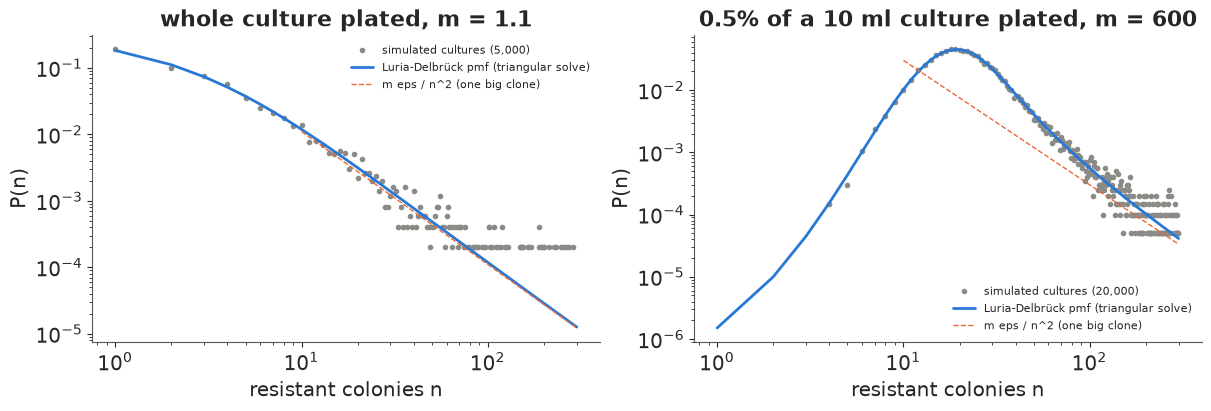

In [6]:
def mss_recursion(m, N):
    p = np.zeros(N + 1)
    p[0] = np.exp(-m)
    for n in range(1, N + 1):
        p[n] = m / n * np.sum(p[:n] / (n - np.arange(n) + 1))
    return p


full = Fluctuation(pd.DataFrame({"experiment": ["check"], "plated": [1.0], "cells_per_culture": [N_T],
                                 "medium": ["-"], "count_lo": [300], "count_hi": [300],
                                 "n_cultures": [1]}), cap=300)
m_chk = 1.1
p_solve = np.exp(full.logpmf_np(m_chk))
print(f"max |solve - MSS recursion| = {np.abs(p_solve - mss_recursion(m_chk, 300)).max():.1e}")
m_sym = pt.dscalar("m")
f_pt = pytensor.function([m_sym], full.logpmf(m_sym))
print(f"max |PyTensor - NumPy| (log p) = {np.abs(f_pt(m_chk) - full.logpmf_np(m_chk)).max():.1e}")

# partial plating: 20,000 simulated 10 ml cultures, 0.05 ml plated, m = 600 mutations per culture
tenml = Fluctuation(ld[ld.experiment == "1"].assign(count_lo=300, count_hi=300), cap=300)
m_10 = 600.0
cult = grow_cultures(m_10 / 3.4e10, 1e3, 3.4e10, 20000, rng)
plated = rng.binomial(cult, tenml.eps)
p_thin = np.exp(tenml.logpmf_np(m_10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
def tv_distance(sample, p):
    """Total variation between a sample's histogram on 0..len(p)-1 (+ one tail cell) and p."""
    emp = np.bincount(np.minimum(sample, len(p)), minlength=len(p) + 1) / len(sample)
    return 0.5 * np.abs(emp - np.append(p, 1 - p.sum())).sum(), emp[:len(p)]


for ax, sim, p, eps, m_, title in [
        (axes[0], spont, p_solve, 1.0, m_chk, "whole culture plated, m = 1.1"),
        (axes[1], plated, p_thin, tenml.eps, m_10, "0.5% of a 10 ml culture plated, m = 600")]:
    n = np.arange(len(p))
    tv, emp = tv_distance(sim, p)
    p_ext = np.append(p, 1 - p.sum())
    tv_ref = np.mean([tv_distance(rng.choice(len(p_ext), len(sim), p=p_ext), p)[0]
                      for _ in range(20)])                      # same-size samples from the pmf itself
    ax.loglog(n[1:], emp[1:], "o", color=GREY, ms=3, label=f"simulated cultures ({len(sim):,})")
    ax.loglog(n[1:], p[1:], color=BLUE, lw=2, label="Luria-Delbrück pmf (triangular solve)")
    ax.loglog(n[10:], m_ * eps / n[10:] ** 2, color=ORANGE, ls="--", lw=1,
              label="m eps / n^2 (one big clone)")
    ax.set(xlabel="resistant colonies n", ylabel="P(n)", title=title)
    print(f"{title}: P(0) simulated {emp[0]:.3f}, model {p[0]:.3f}; P(n <= 300) simulated "
          f"{np.mean(sim <= 300):.4f}, model {p.sum():.4f}; TV distance {tv:.3f} "
          f"(pure sampling noise at this size: {tv_ref:.3f})")
    ax.legend(fontsize=8)
del cult, plated

The solve agrees with the recursion to rounding error, and the PyTensor graph with the NumPy one.
The distribution matches the simulated cultures in both regimes, including the zeros and the
probability mass beyond 300. The total-variation distances are what sampling noise alone gives
for samples of this size (printed next to them). (The physical simulation
starts from $N_0 = 1000$ cells, not from zero as the Lea-Coulson limit assumes; the difference is
invisible at this scale.) The tail approaches $m\varepsilon/n^2$ (dashed), the chance that a single
early clone put $n$ cells on the plate: that is the jackpot, and it is why the
**mean number of mutants is useless** (infinite in the limit) while the **probabilities** are
perfectly well behaved. Thinning ($\varepsilon = 0.005$) does not change the tail exponent, only
where it starts: with 600 clones per culture the plate count has a body around 20 and bends into
the $n^{-2}$ tail only beyond about 200.

## 4 · One experiment, five estimators

Experiment 23 plated whole cultures, which makes every classic estimator applicable. With $C$
cultures:

- **Mean method** (Luria & Delbrück's equation 8): the average count $\bar r$ satisfies
  $\bar r = m \ln(C m)$; solve for $m$. It uses the mean, which the jackpots dominate.
- **$p_0$ method** (their equation 5): the share of cultures with no mutant is $e^{-m}$, so
  $m = -\ln p_0$. It throws away every non-zero count and fails when $m > 4$ or so (no zeros).
- **Lea-Coulson median**: $\tilde r/m - \ln m = 1.24$. Designed for $m$ of about 4 or more.
- **Maximum likelihood** with the distribution of section 3 (the modern standard, e.g. in the
  rSalvador and flan R packages).
- **Bayesian posterior** of the same likelihood, which gives an interval that respects the
  skewness of the likelihood.

Luria and Delbrück report $\bar r = 28.6$ resistant bacteria per culture in experiment 23 (the
classes alone do not give the mean). We report $\mu = m/N_t$, mutations per cell per
division - numerically the same as their "mutation rate per bacterium per time unit" (they also
quote a per-division-cycle value, smaller by a factor $\ln 2$, from a different time convention).

In [7]:
e23 = series[names.index("23")]
C23, R_BAR23 = len(e23.lo), 28.6
n_zero = int(np.sum(e23.hi == 0))
m_mean = optimize.brentq(lambda m: m * np.log(C23 * m) - R_BAR23, 0.05, 100)
m_p0 = -np.log(n_zero / C23)
median23 = np.median(e23.lo)
m_median = optimize.brentq(lambda m: median23 / m - np.log(m) - 1.24, 0.01, 50)
assert np.allclose(e23.loglik_np(e23.logpmf_np(1.1)),                 # NumPy == PyTensor
                   pytensor.function([], e23.loglik(pt.as_tensor(e23.logpmf_np(1.1))))())
m_mle = float(np.exp(optimize.minimize_scalar(
    lambda lm: -e23.loglik_np(e23.logpmf_np(np.exp(lm))).sum(),
    bounds=(np.log(0.2), np.log(10)), method="bounded").x))

with pm.Model() as m23:
    log10_mu = pm.Normal("log10_mu", -8.0, 1.0)
    m = pm.Deterministic("m", 10 ** log10_mu * e23.cells)
    pm.Potential("lik", e23.loglik(e23.logpmf(m)).sum())
    idata23 = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(idata23, var_names=["log10_mu", "m"], round_to=3))
print("divergences:", int(idata23.sample_stats["diverging"].sum()),
      "| tuning steps:", idata23.posterior.attrs.get("tuning_steps"))

m_post = idata23.posterior["m"].to_numpy().ravel()
est = pd.DataFrame({
    "m": [m_mean, m_p0, m_median, m_mle, np.median(m_post)],
    "89% interval": ["", "", "", "", f"{np.quantile(m_post, 0.055):.2f}-{np.quantile(m_post, 0.945):.2f}"]},
    index=["mean (LD eq. 8)", f"p0 ({n_zero}/{C23} zeros)", f"Lea-Coulson median (median {median23:.0f})",
           "maximum likelihood", "posterior median"])
est["mu = m / N_t (x 1e-8)"] = (est["m"] / e23.cells * 1e8).round(2)
print(est.round(2).to_string())

           mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
log10_mu -8.295  0.054    -8.383    -8.214  1467.836  2004.776  1.002   
m         1.226  0.152     0.994     1.467  1467.836  2004.776  1.002   

          mcse_mean  mcse_sd  
log10_mu      0.001    0.001  
m             0.004    0.002  
divergences: 0 | tuning steps: 400
                                  m 89% interval  mu = m / N_t (x 1e-8)
mean (LD eq. 8)                4.74                                1.98
p0 (29/88 zeros)               1.11                                0.46
Lea-Coulson median (median 1)  0.89                                0.37
maximum likelihood             1.22                                0.51
posterior median               1.22    0.99-1.47                   0.51


The estimators disagree by a factor of four. The **mean method** gives $\mu \approx 2 \times 10^{-8}$
(Luria and Delbrück's Table 4 lists $2.4 \times 10^{-8}$ for this experiment; we cannot reproduce
their number from the printed mean with equation 8, but the order is the same). The **$p_0$
method**, the **MLE** and the **posterior** agree on 1.1-1.2 mutations per culture,
$\mu \approx 0.5 \times 10^{-8}$ (Luria and Delbrück's own $p_0$ value was $0.47 \times 10^{-8}$), with
the posterior giving an 89% interval of about 1.0-1.5. The median method is lower (0.9); with a
median of 1 it is far outside the range the formula was made for. Luria and Delbrück noticed that their mean-method rates
were "all higher" than the $p_0$ rate and blamed an excess of early mutations: the jackpots. Which
estimator is right in general? A simulation study answers that better than one data set: draw
many experiments from the model with a known $m$ and estimate $m$ each time.

true m = 1.1, 87 cultures, 400 simulated experiments
        median ratio  log2 5%  log2 95%  undefined
mean            1.27    -0.41      2.52        0.0
p0              1.00    -0.27      0.32        0.0
median          0.81    -0.31      0.26        0.0
MLE             0.99    -0.26      0.24        0.0
true m = 20.0, 30 cultures, 400 simulated experiments
        median ratio  log2 5%  log2 95%  undefined
mean            1.20    -0.30      1.71        0.0
p0               NaN      NaN       NaN        1.0
median          1.01    -0.25      0.32        0.0
MLE             1.00    -0.25      0.19        0.0


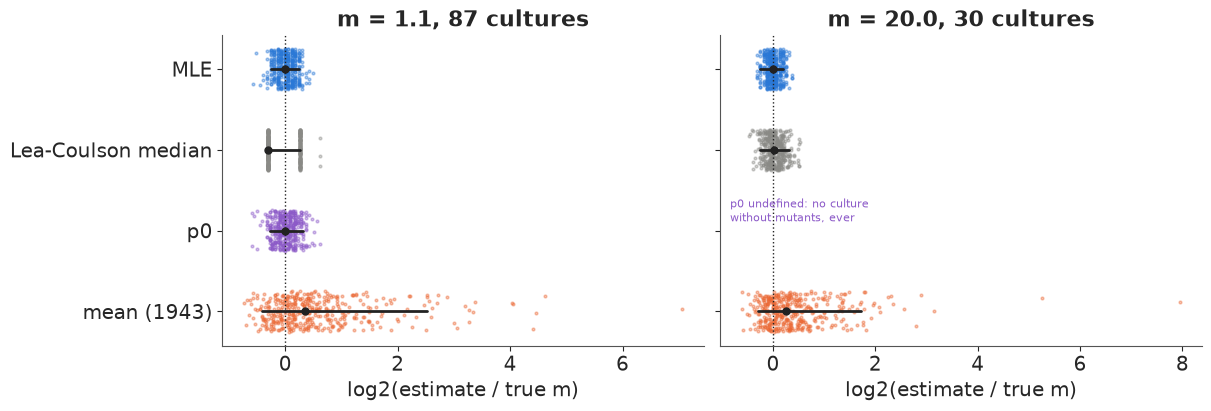

In [8]:
def simulate_experiment(m, n_cultures, rng):
    """Whole-culture counts from the Lea-Coulson model: Poisson(m) clones of size 1/(k(k+1))."""
    k = rng.poisson(m, n_cultures)
    u = rng.uniform(size=k.sum())
    clones = rng.geometric(np.maximum(u, 1e-12))
    return np.bincount(np.repeat(np.arange(n_cultures), k), weights=clones,
                       minlength=n_cultures).astype(np.int64)


CAP_SIM = 2000
grid_sim = np.exp(np.linspace(np.log(0.1), np.log(100), 160))
big = Fluctuation(pd.DataFrame({"experiment": ["sim"], "plated": [1.0], "cells_per_culture": [N_T],
                                "medium": ["-"], "count_lo": [CAP_SIM], "count_hi": [CAP_SIM],
                                "n_cultures": [1]}), cap=CAP_SIM)
LOGP = np.array([big.logpmf_np(m) for m in grid_sim])                   # (grid, 0..CAP_SIM)
LOGP_TAIL = np.log1p(-np.minimum(np.exp(LOGP).sum(axis=1), 1 - 1e-15))   # "more than CAP_SIM"
del big


def estimators(r):
    C = len(r)
    out = {"mean": optimize.brentq(lambda m: m * np.log(C * m) - r.mean(), 1e-3, 1e5)}
    z = np.mean(r == 0)
    out["p0"] = -np.log(z) if z > 0 else np.nan
    med = np.median(r)
    out["median"] = (optimize.brentq(lambda m: med / m - np.log(m) - 1.24, 1e-3, 1e4)
                     if med > 0 else np.nan)
    counts = np.bincount(np.minimum(r, CAP_SIM + 1), minlength=CAP_SIM + 2)
    ll = LOGP @ counts[:CAP_SIM + 1] + LOGP_TAIL * counts[CAP_SIM + 1]
    out["MLE"] = grid_sim[np.argmax(ll)]
    return out


designs = [(1.1, 87), (20.0, 30)]
study = {}
for m_true, C in designs:
    rows = [estimators(simulate_experiment(m_true, C, rng)) for _ in range(400)]
    study[(m_true, C)] = pd.DataFrame(rows)
    summary = {}
    for k, v in study[(m_true, C)].items():
        r = np.log2(v.dropna() / m_true)
        summary[k] = ({"median ratio": 2 ** r.median(), "log2 5%": r.quantile(0.05),
                       "log2 95%": r.quantile(0.95)} if len(r) else {}) | {"undefined": v.isna().mean()}
    print(f"true m = {m_true}, {C} cultures, 400 simulated experiments")
    print(pd.DataFrame(summary).T.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (m_true, C) in zip(axes, designs):
    s = study[(m_true, C)]
    for i, (k, c) in enumerate(zip(s.columns, [ORANGE, PURPLE, GREY, BLUE])):
        v = np.log2(s[k].dropna() / m_true)
        if len(v) == 0:
            continue
        ax.scatter(v, i + rng.uniform(-0.25, 0.25, len(v)), s=4, color=c, alpha=0.4)
        ax.plot(np.quantile(v, [0.05, 0.95]), [i, i], color=INK, lw=2)
        ax.plot(np.median(v), i, "o", color=INK, ms=5)
    ax.axvline(0, color=INK, ls=":", lw=1)
    ax.set_yticks(range(4), ["mean (1943)", "p0", "Lea-Coulson median", "MLE"])
    ax.set(xlabel="log2(estimate / true m)", title=f"m = {m_true}, {C} cultures")
axes[1].text(0.02, 0.4, "p0 undefined: no culture\nwithout mutants, ever", transform=axes[1].transAxes,
             fontsize=8, color=PURPLE);

The simulation study (400 simulated experiments per design) makes the ranking general. The
**mean method** is biased upwards (median 20% high) and has by far the widest scatter, up to
fourfold too high in 5% of experiments: whether an experiment happened to contain one giant jackpot
decides the answer. **$p_0$** is unbiased at $m = 1.1$ (within about 25% in 90% of experiments)
but, with $m = 20$, no culture is ever free of mutants and it does not exist. The **median** method
is biased about 20% low at $m = 1.1$ - with a median of 0, 1 or 2 it can take only a few values -
and fine at $m = 20$, where it was designed to work. **Maximum likelihood** is centred on the truth
in both designs with the narrowest spread (within about 20-25% in 90% of experiments). The posterior uses the same likelihood, so it inherits these
properties and adds an honest interval. That is why the field moved to likelihood-based
estimation in the 1990s-2000s (Ma, Sandri & Sarkar; Rosche & Foster 2000; Zheng's rSalvador) and
why a heavy-tailed likelihood that a sampler can use matters.

## 5 · Induced or spontaneous? All ten experiments

Now the question of 1943, with all 281 cultures. Each experiment gets its own rate, tied together
by a hierarchical prior (section 6 looks at that part):

$$\log_{10}\text{rate}_e = \beta_0 + \beta_\text{syn}\,[\text{synthetic medium}]_e + \tau z_e,
\qquad z_e \sim N(0, 1).$$

- **Induced**: plated colonies are Poisson with mean $a_e N_e \varepsilon_e$.
- **Spontaneous**: the Luria-Delbrück distribution with $m_e = \mu_e N_e$, thinned by the
  plated fraction $\varepsilon_e$.

Priors: $\beta_0 \sim N(-8, 1)$ (a rate between $10^{-10}$ and $10^{-6}$ per cell is plausible
for a single-gene phenotype; in experiment 23 that is 0.02-200 mutations per culture),
$\beta_\text{syn} \sim N(0, 0.5)$ (no medium effect expected, a threefold one allowed), $\tau \sim
\text{HalfNormal}(0.3)$ (experiments agree to within a factor of about 2). The likelihood is a
`pm.Potential`, so we store each culture's log-likelihood as a `Deterministic` and hand it to
ArviZ for PSIS-LOO ourselves.

In [9]:
SYN = np.array([s.synthetic for s in series], dtype=float)
coords = {"experiment": names, "culture": np.arange(sum(len(s.lo) for s in series))}


def fluctuation_model(kind="spontaneous", induced_extra=False, fitness=False):
    with pm.Model(coords=coords) as model:
        b0 = pm.Normal("b0", -8.0, 1.0)
        b_syn = pm.Normal("b_syn", 0.0, 0.5)
        tau = pm.HalfNormal("tau", 0.3)
        z = pm.Normal("z", 0.0, 1.0, dims="experiment")
        log10_rate = pm.Deterministic("log10_rate", b0 + b_syn * SYN + tau * z, dims="experiment")
        if induced_extra:                                  # one induced rate shared by all
            log10_a = pm.Normal("log10_a", -8.0, 1.0)
        rho = pm.LogNormal("rho", 0.0, 0.5) if fitness else None
        lls = []
        for k, s in enumerate(series):
            if kind == "induced":
                lls.append(s.loglik_poisson(10 ** log10_rate[k] * s.cells * s.eps))
                continue
            lam = 10 ** log10_a * s.cells * s.eps if induced_extra else 0.0
            lls.append(s.loglik(s.logpmf(10 ** log10_rate[k] * s.cells, lam, rho)))
        ll = pm.Deterministic("ll", pt.concatenate(lls), dims="culture")
        pm.Potential("likelihood", ll.sum())
    return model


def fit(model, **kw):
    t0 = time.time()
    idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, model=model, **kw)
    idata["log_likelihood"] = idata.posterior["ll"].to_dataset(name="y")
    idata["posterior"] = idata.posterior.to_dataset().drop_vars("ll")
    loo = az.loo(idata, var_name="y", pointwise=True)
    loo.log_weights = None
    del idata["log_likelihood"]
    st = idata.sample_stats
    print(f"{time.time() - t0:.0f} s | divergences {int(st['diverging'].sum())} | "
          f"max r_hat {float(az.rhat(idata).to_dataset().to_dataarray().max()):.3f} | "
          f"min ess_bulk {float(az.ess(idata).to_dataset().to_dataarray().min()):.0f} | "
          f"elpd_loo {loo.elpd:.1f} | Pareto k > 0.7: {int((loo.pareto_k > 0.7).sum())}")
    return idata, loo


fits, loos = {}, {}
fits["induced"], loos["induced"] = fit(fluctuation_model("induced"))
fits["spontaneous"], loos["spontaneous"] = fit(fluctuation_model("spontaneous"), target_accept=0.9)
print(az.compare({k: loos[k] for k in ["induced", "spontaneous"]}, round_to=1)[
    ["rank", "elpd", "elpd_diff", "dse", "p"]])

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


23 s | divergences 0 | max r_hat 1.007 | min ess_bulk 517 | elpd_loo -5700.6 | Pareto k > 0.7: 18


15 s | divergences 0 | max r_hat 1.006 | min ess_bulk 780 | elpd_loo -671.2 | Pareto k > 0.7: 0
             rank    elpd  elpd_diff    dse      p
spontaneous     0  -671.2        0.0    0.0   12.8
induced         1 -5700.6    -5029.5  960.4  481.1


Both samplers ran cleanly (no divergences, r_hat at most 1.01). The comparison is not close: the
spontaneous model's expected log predictive density is higher by about 5,000 units, five times
its (large) standard error. The induced model also has 18 cultures with Pareto $k > 0.7$ - single
jackpot cultures that the Poisson fit cannot predict without having seen them; its LOO estimate is
unreliable, but only in the direction of being even worse. A predictive check shows the same thing in
a picture: for each experiment, the **largest** count among its cultures, observed vs. replicated
from each posterior.

induced     : observed maximum inside the 90% predictive interval in 0 of 10 series; above it in 10 (1, 10, 11, 15, 16, 17, 21a, 21b, 22, 23)
spontaneous : observed maximum inside the 90% predictive interval in 9 of 10 series; above it in 1 (17)


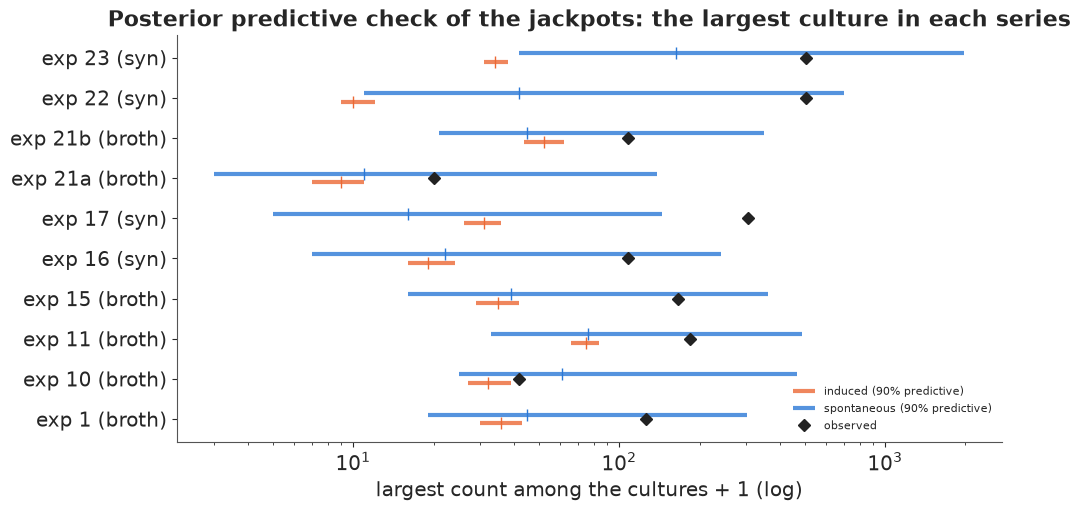

In [10]:
def replicate_counts(s, m, lam, rho, rng):
    """Posterior predictive counts for one series: thinned clones + induced singles."""
    k = rng.poisson(m)
    u = rng.uniform(size=k.sum())
    p = np.maximum(u ** (1.0 / rho), 1.0 / s.cells)            # geometric parameter, fitness 1/rho
    plated = rng.binomial(rng.geometric(p), s.eps)
    idx = np.repeat(np.arange(len(m)), k)
    return np.bincount(idx, weights=plated, minlength=len(m)).astype(np.int64) + rng.poisson(lam, len(m))


def ppc_max(idata, kind, n_draws=300, lam_var=None, rho_var=None):
    extra = az.extract(idata, num_samples=n_draws, random_seed=RANDOM_SEED)
    post = extra["log10_rate"].transpose("experiment", "sample").to_numpy()
    out = np.zeros((len(series), n_draws))
    stat_rng = np.random.default_rng(RANDOM_SEED)
    for k, s in enumerate(series):
        for d in range(n_draws):
            if kind == "induced":
                r = stat_rng.poisson(10 ** post[k, d] * s.cells * s.eps, len(s.lo))
            else:
                lam = 10 ** float(extra[lam_var][d]) * s.cells * s.eps if lam_var else 0.0
                rho = float(extra[rho_var][d]) if rho_var else 1.0
                r = replicate_counts(s, np.full(len(s.lo), 10 ** post[k, d] * s.cells), lam, rho,
                                     stat_rng)
            out[k, d] = r.max()
    return out


obs_max = np.array([s.lo.max() for s in series])        # 501 in exps 22, 23 means "at least 501"
ppc = {k: ppc_max(fits[k], k) for k in ["induced", "spontaneous"]}
for k, rep in ppc.items():
    lo, hi = np.quantile(rep, [0.05, 0.95], axis=1)
    print(f"{k:12s}: observed maximum inside the 90% predictive interval in "
          f"{np.sum((obs_max >= lo) & (obs_max <= hi))} of {len(series)} series; above it in "
          f"{np.sum(obs_max > hi)} ({', '.join(np.array(names)[obs_max > hi])})")


def plot_ppc_max(ax, ppcs, colours):
    for j, ((label, rep), c) in enumerate(zip(ppcs.items(), colours)):
        y = np.arange(len(series)) + (j - (len(ppcs) - 1) / 2) * 0.22
        lo, mid, hi = np.quantile(rep + 1, [0.05, 0.5, 0.95], axis=1)
        ax.hlines(y, lo, hi, color=c, lw=3, alpha=0.8, label=f"{label} (90% predictive)")
        ax.plot(mid, y, "|", color=c, ms=8)
    ax.plot(obs_max + 1, np.arange(len(series)), "D", color=INK, ms=6, label="observed")
    ax.set_xscale("log")
    ax.set_yticks(range(len(series)), [f"exp {n} ({'syn' if s.synthetic else 'broth'})"
                                       for n, s in zip(names, series)])
    ax.set(xlabel="largest count among the cultures + 1 (log)")
    ax.legend(fontsize=8, loc="lower right")


fig, ax = plt.subplots(figsize=(10, 5))
plot_ppc_max(ax, ppc, [ORANGE, BLUE])
ax.set_title("Posterior predictive check of the jackpots: the largest culture in each series");

Under induction (orange) the largest culture of every series should be within a factor of about
two of the typical count. The observed maxima (black diamonds; for experiments 22 and 23 the
lower edge of the "more than 500" class) are above those intervals in all ten series. Under
spontaneous mutation (blue) the predictive intervals of the maximum span one to two orders of
magnitude - that is what jackpots look like - and nine of the ten observed maxima fall inside them.
The exception is experiment 17, whose one culture with 303 colonies is above the interval.
The spontaneous model is right about the **kind** of variation. Whether it gets the size of the tail
right is section 7.

## 6 · One mutation rate? A hierarchical model across experiments and media

Luria and Delbrück concluded from their Table 4 (mean method) that the mutation rate "does not
vary greatly from experiment to experiment" and does not differ between broth and synthetic
medium, despite very different growth rates. The hierarchical model asks the same question with
the full likelihood.

        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
b0    -7.899  0.065    -8.001    -7.799   995.897  1165.614  1.006      0.002   
b_syn -0.505  0.102    -0.664    -0.347  1221.523  1565.647  1.006      0.003   
tau    0.124  0.058     0.042     0.220   779.875   956.344  1.002      0.002   

       mcse_sd  
b0       0.002  
b_syn    0.003  
tau      0.002  
synthetic / broth mutation rate: 0.31 (89% interval 0.22-0.45); P(lower in synthetic) = 1.000
                        1    10    11    15   16    17   21a   21b    22    23
posterior median     1.13  1.32  1.48  1.05  0.3  0.37  1.19  1.71  0.43  0.48
LD Table 4           1.80  1.40  4.10  2.10  1.1  3.00  3.30  3.00  2.30  2.40
Table 4 / posterior  1.60  1.10  2.80  2.00  3.6  8.10  2.80  1.80  5.40  5.00


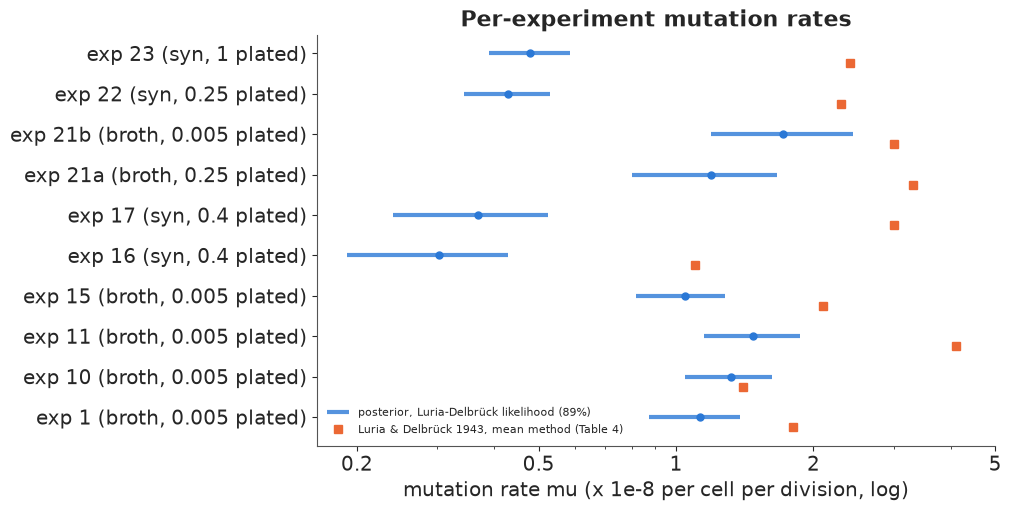

In [11]:
LD_TABLE4 = {"1": 1.8, "10": 1.4, "11": 4.1, "15": 2.1, "16": 1.1, "17": 3.0, "21a": 3.3,
             "21b": 3.0, "22": 2.3, "23": 2.4}                   # x 1e-8, mean method (Table 4)
print(az.summary(fits["spontaneous"], var_names=["b0", "b_syn", "tau"], round_to=3))
bs = fits["spontaneous"].posterior["b_syn"].to_numpy().ravel()
print(f"synthetic / broth mutation rate: {np.median(10 ** bs):.2f} "
      f"(89% interval {np.quantile(10 ** bs, 0.055):.2f}-{np.quantile(10 ** bs, 0.945):.2f}); "
      f"P(lower in synthetic) = {np.mean(bs < 0):.3f}")


def log_ticks(ax, ticks=(0.2, 0.5, 1, 2, 5)):
    ax.set_xscale("log")
    ax.set_xticks(ticks, [f"{t:g}" for t in ticks])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())


def plot_rates(ax, idata, colour, label, offset):
    r = 10 ** (idata.posterior["log10_rate"].to_numpy().reshape(-1, len(series)) + 8)
    lo, mid, hi = np.quantile(r, [0.055, 0.5, 0.945], axis=0)
    y = np.arange(len(series)) + offset
    ax.hlines(y, lo, hi, color=colour, lw=3, alpha=0.8, label=label)
    ax.plot(mid, y, "o", color=colour, ms=5)


fig, ax = plt.subplots(figsize=(10, 5))
plot_rates(ax, fits["spontaneous"], BLUE, "posterior, Luria-Delbrück likelihood (89%)", 0.0)
ax.plot([LD_TABLE4[n] for n in names], np.arange(len(series)) - 0.25, "s", color=ORANGE,
        label="Luria & Delbrück 1943, mean method (Table 4)")
log_ticks(ax)
ax.set_yticks(range(len(series)), [f"exp {n} ({'syn' if s.synthetic else 'broth'}, "
                                   f"{s.eps:.3g} plated)" for n, s in zip(names, series)])
ax.set(xlabel="mutation rate mu (x 1e-8 per cell per division, log)",
       title="Per-experiment mutation rates")
ax.legend(fontsize=8);
post_med = np.median(10 ** (fits["spontaneous"].posterior["log10_rate"].to_numpy().reshape(-1, len(series)) + 8),
                     axis=0)
print(pd.DataFrame({"posterior median": post_med.round(2), "LD Table 4": [LD_TABLE4[n] for n in names],
                    "Table 4 / posterior": (np.array([LD_TABLE4[n] for n in names]) / post_med).round(1)},
                   index=names).T.to_string())

Two things change with the likelihood. First, **every** rate is lower than the mean-method value,
by a factor of 1.1 (experiment 10) to 8 (experiment 17) - the jackpot bias of section 4, now in
every experiment. Second, the experiments separate into two groups: the synthetic-medium series
(16, 17, 22, 23) come out about **three times lower** than the broth series (ratio 0.31, 89%
interval 0.22-0.45), and every posterior draw has "lower in synthetic". The mean method's noise had hidden this; Luria and
Delbrück's conclusion of "no difference" does not survive the full likelihood - at least not with
this model. Before believing it we have to ask whether the model is adequate: the broth series
are mostly the 10 ml cultures with only 0.5% plated, whose counts are made almost entirely of
large clones, so their rates depend on the **shape of the tail** more than any other series.
The remaining between-experiment spread is small ($\tau \approx 0.12$ in $\log_{10}$, about 30%).

## 7 · Is the tail heavy enough?

Holmes, Ghafari, Abbas, Saravanan & Nemenman (2017, arXiv:1701.05627) re-analysed experiments 22
and 23 and found that experiment 23 has a tail heavier than the Luria-Delbrück model predicts, and
that a model with **both** induced and spontaneous resistance could not be ruled out on
experiment 22. We test two extensions on all ten series:

1. **Induced + spontaneous**: one extra Poisson($a N \varepsilon$) of induced survivors, with the
   induced probability $a$ shared by all experiments (it is a property of the cell-phage
   encounter). This makes the **body** of the distribution more Poisson-like; it cannot fatten
   the tail.
2. **Differential growth** (Mandelbrot-Koch): mutants grow at relative rate $w = 1/\rho$; $\rho < 1$
   (faster mutants) fattens the tail, $\rho > 1$ thins it. Prior $\rho \sim \text{LogNormal}(0, 0.5)$.

We look at experiment 23's frequency table under each model after fitting them.

In [12]:
fits["induced + spontaneous"], loos["induced + spontaneous"] = fit(
    fluctuation_model("spontaneous", induced_extra=True), target_accept=0.9)
fits["fitness"], loos["fitness"] = fit(fluctuation_model("spontaneous", fitness=True),
                                       target_accept=0.9)
print(az.compare(loos, round_to=1)[["rank", "elpd", "elpd_diff", "dse", "p", "weight"]])
print(az.summary(fits["fitness"], var_names=["rho", "b0", "b_syn", "tau"], round_to=3))
print(az.summary(fits["induced + spontaneous"], var_names=["log10_a"], round_to=3))

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


21 s | divergences 0 | max r_hat 1.004 | min ess_bulk 867 | elpd_loo -672.0 | Pareto k > 0.7: 1


38 s | divergences 0 | max r_hat 1.003 | min ess_bulk 778 | elpd_loo -649.2 | Pareto k > 0.7: 0
                       rank    elpd  elpd_diff    dse      p  weight
fitness                   0  -649.2        0.0    0.0    8.2     1.0
spontaneous               1  -671.2      -21.9    6.8   12.8     0.0
induced + spontaneous     2  -672.0      -22.7    6.9   12.8     0.0
induced                   3 -5700.6    -5051.4  964.6  481.1     0.0
        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
rho    0.711  0.042     0.642     0.778  1756.089  1889.831  1.000      0.001   
b0    -8.326  0.103    -8.494    -8.169  1217.472  1417.030  1.001      0.003   
b_syn -0.148  0.122    -0.349     0.043  1200.586  1078.378  1.003      0.004   
tau    0.125  0.067     0.033     0.238   777.962   914.233  1.003      0.002   

       mcse_sd  
rho      0.001  
b0       0.002  
b_syn    0.003  
tau      0.003  
          mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat

In [13]:
a_post = fits["induced + spontaneous"].posterior["log10_a"].to_numpy().ravel()
mu23 = 10 ** fits["induced + spontaneous"].posterior["log10_rate"].sel(experiment="23").to_numpy().ravel()
lam23 = 10 ** a_post * e23.cells
print(f"induced resistance probability a: 95% upper bound {10 ** np.quantile(a_post, 0.95):.1e} per cell"
      f" | experiment 23: induced survivors per culture (95% upper) {np.quantile(lam23, 0.95):.2f}"
      f" vs mutations per culture {np.median(mu23 * e23.cells):.2f}")
rho_post = fits["fitness"].posterior["rho"].to_numpy().ravel()
print(f"relative growth rate of mutants w = 1/rho: {np.median(1 / rho_post):.2f} "
      f"(89% interval {np.quantile(1 / rho_post, 0.055):.2f}-{np.quantile(1 / rho_post, 0.945):.2f})")
bs_f = fits["fitness"].posterior["b_syn"].to_numpy().ravel()
print(f"fitness model: synthetic / broth rate {np.median(10 ** bs_f):.2f} "
      f"(89% {np.quantile(10 ** bs_f, 0.055):.2f}-{np.quantile(10 ** bs_f, 0.945):.2f}); "
      f"P(lower in synthetic) = {np.mean(bs_f < 0):.3f}")

induced resistance probability a: 95% upper bound 4.9e-10 per cell | experiment 23: induced survivors per culture (95% upper) 0.12 vs mutations per culture 1.13
relative growth rate of mutants w = 1/rho: 1.41 (89% interval 1.29-1.56)
fitness model: synthetic / broth rate 0.72 (89% 0.45-1.10); P(lower in synthetic) = 0.893


induced                observed class count inside its 90% interval: 0/13; above: ['0', '1', '2', '3', '4', '5', '6-10', '51-100', '101-200', '201-500', '>500']; below: ['11-20', '21-50']
spontaneous            observed class count inside its 90% interval: 10/13; above: ['51-100', '201-500']; below: ['2']
induced + spontaneous  observed class count inside its 90% interval: 10/13; above: ['51-100', '201-500']; below: ['2']
spontaneous + fitness  observed class count inside its 90% interval: 12/13; above: ['201-500']; below: []


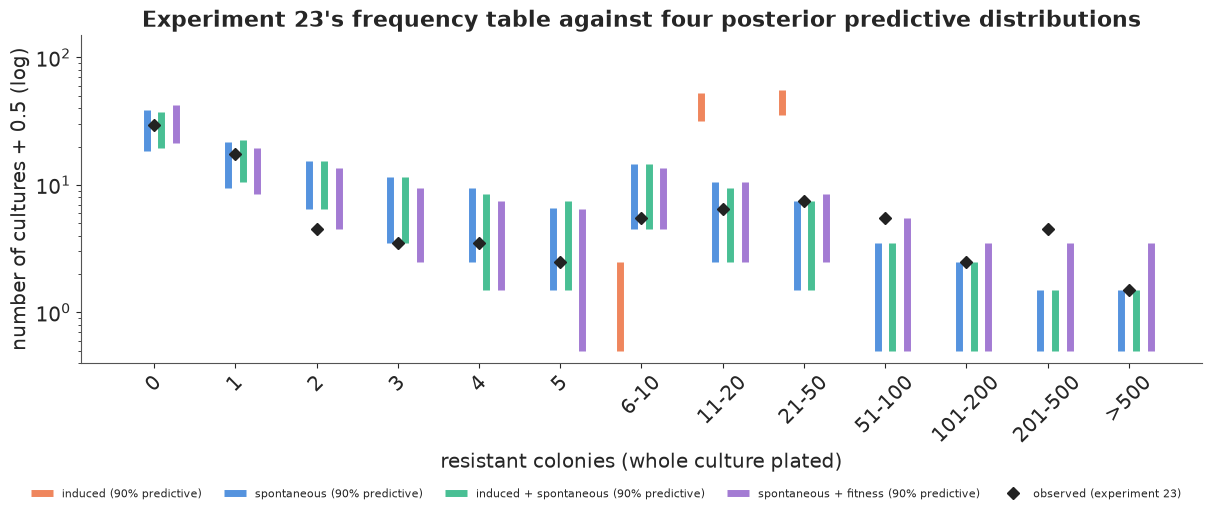

In [14]:
classes = tab3[tab3.experiment == "23"][["count_lo", "count_hi", "n_cultures"]].to_numpy()
cls_hi = np.where(classes[:, 1] == 1000, np.inf, classes[:, 1])       # top class read as "> 500"
cls_labels = [f"{lo}" if lo == hi else (f"{lo}-{hi:.0f}" if hi < np.inf else f">{lo - 1}")
              for lo, hi in zip(classes[:, 0], cls_hi)]


def ppc_classes(idata, kind, rho_var=None, lam_var=None, n_draws=400):
    post = az.extract(idata, num_samples=n_draws, random_seed=RANDOM_SEED)
    lr = post["log10_rate"].sel(experiment="23").to_numpy()
    rr = np.random.default_rng(RANDOM_SEED)
    out = np.zeros((n_draws, len(classes)))
    for d in range(n_draws):
        if kind == "induced":
            r = rr.poisson(10 ** lr[d] * e23.cells, C23)
        else:
            rho = float(post[rho_var][d]) if rho_var else 1.0
            lam = 10 ** float(post[lam_var][d]) * e23.cells if lam_var else 0.0
            r = replicate_counts(e23, np.full(C23, 10 ** lr[d] * e23.cells), lam, rho, rr)
        out[d] = [np.sum((r >= lo) & (r <= hi)) for lo, hi in zip(classes[:, 0], cls_hi)]
    return out


fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(classes))
for j, (label, rep, c) in enumerate([
        ("induced", ppc_classes(fits["induced"], "induced"), ORANGE),
        ("spontaneous", ppc_classes(fits["spontaneous"], "spontaneous"), BLUE),
        ("induced + spontaneous", ppc_classes(fits["induced + spontaneous"], "spontaneous",
                                              lam_var="log10_a"), AQUA),
        ("spontaneous + fitness", ppc_classes(fits["fitness"], "spontaneous", rho_var="rho"), PURPLE)]):
    lo, hi = np.quantile(rep, [0.05, 0.95], axis=0)
    xx = x + (j - 1.5) * 0.18
    ax.vlines(xx, lo + 0.5, hi + 0.5, color=c, lw=5, alpha=0.8, label=f"{label} (90% predictive)")
    print(f"{label:22s} observed class count inside its 90% interval: "
          f"{np.sum((classes[:, 2] >= lo) & (classes[:, 2] <= hi))}/{len(classes)}; above: "
          f"{[cls_labels[i] for i in np.where(classes[:, 2] > hi)[0]]}; below: "
          f"{[cls_labels[i] for i in np.where(classes[:, 2] < lo)[0]]}")
ax.plot(x, classes[:, 2] + 0.5, "D", color=INK, ms=6, label="observed (experiment 23)")
ax.set_yscale("log")
ax.set_ylim(0.4, 150)
ax.set_xticks(x, cls_labels, rotation=45)
ax.set(xlabel="resistant colonies (whole culture plated)", ylabel="number of cultures + 0.5 (log)",
       title="Experiment 23's frequency table against four posterior predictive distributions")
fig.legend(fontsize=8, ncols=5, loc="outside lower center");

The comparison and the picture tell the same story.

- **Induced + spontaneous** adds nothing: its expected log predictive density is no better than the
  pure spontaneous model, the induced probability is pushed down to where it is irrelevant (upper
  bound above: a small fraction of one induced survivor per culture in experiment 23, next to about one
  mutation per culture), and its predictive distribution for experiment 23 (aqua) is the same as the
  spontaneous one (blue). On these data, with this prior, there is no sign of induced resistance -
  but the data cannot exclude a small amount of it either, which is Holmes et al.'s point.
- **The tail is heavier than Luria-Delbrück.** In experiment 23 the pure spontaneous model
  under-predicts the classes 51-100 and 201-500 (5 and 4 cultures observed, above its 90%
  intervals) and over-predicts the class "2": the data have more big jackpots and fewer small
  clones than a neutral Luria-Delbrück culture. The fitness extension (purple) covers 12 of the 13
  classes; only 201-500 stays just above its interval. The induced model (orange) misses every class.
- **The fitness model wins clearly on PSIS-LOO** (22 units of elpd, three standard errors),
  with $\rho \approx 0.7$: taken literally, resistant mutants that grow about 40% **faster** than
  their sensitive parents. That literal reading is suspicious - there is no obvious reason for
  phage-resistant mutants to outgrow the wild type in phage-free broth. The same heavier tail
  arises if mutations happen preferentially early (Luria and Delbrück's own suggestion: a higher
  mutation rate in actively growing cells), if cultures were sometimes seeded with a pre-existing
  mutant, or if resistant cells clump or are counted differently on the plate. The fitness
  parameter is best read as a **tail-shape parameter** that the data demand, not as a measured
  growth rate.
- **It matters for the rates.** With the heavier tail, the jackpots no longer need a high mutation
  rate to explain them. The broth 10 ml series move down the most, and the broth-synthetic ratio
  becomes 0.72 (89% interval 0.45-1.10; 89% of draws below 1): a difference that may exist but is
  no longer clear. Conclusions about the rate and about media depend on getting the tail right.

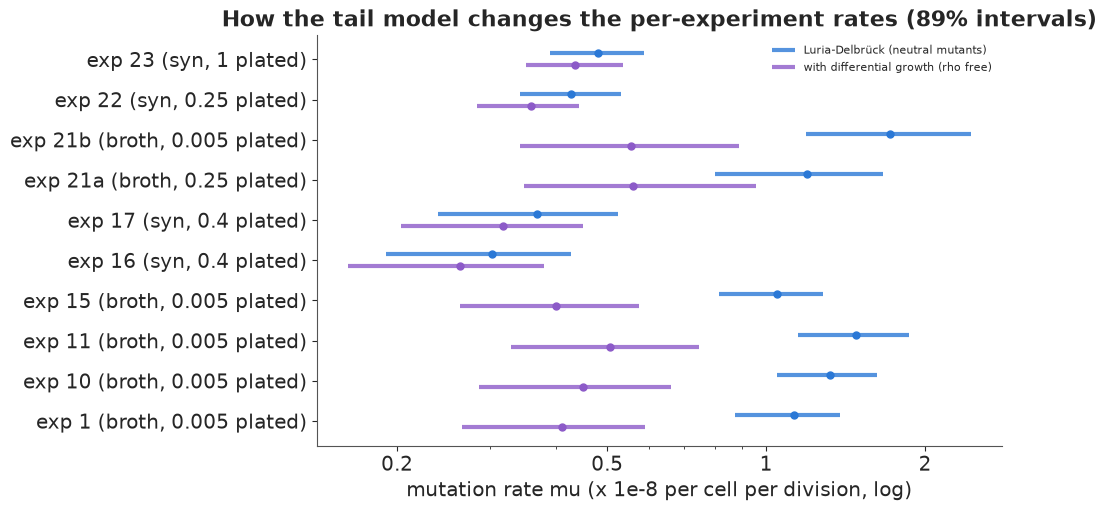

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_rates(ax, fits["spontaneous"], BLUE, "Luria-Delbrück (neutral mutants)", 0.15)
plot_rates(ax, fits["fitness"], PURPLE, "with differential growth (rho free)", -0.15)
log_ticks(ax, (0.2, 0.5, 1, 2))
ax.set_yticks(range(len(series)), [f"exp {n} ({'syn' if s.synthetic else 'broth'}, "
                                   f"{s.eps:.3g} plated)" for n, s in zip(names, series)])
ax.set(xlabel="mutation rate mu (x 1e-8 per cell per division, log)",
       title="How the tail model changes the per-experiment rates (89% intervals)")
ax.legend(fontsize=8);

The synthetic series with whole or large-fraction plating (16, 17, 22, 23) barely move: their
counts are dominated by zeros and small counts, which pin down $m$ whatever the tail. The 10 ml
broth series with 0.5% plated (1, 10, 11, 15, 21b) drop by a factor of about 2.5-3: on their plates
**only** large clones show up, so their rates are extrapolations through the tail. Experiment 21a
(broth, 0.2 ml, mostly zeros) also halves, but for a different reason: it has little information
of its own and is pulled along with the other broth series by the hierarchical prior. That is a
lesson for design as much as for analysis: plating a tiny fraction of a huge culture makes the
mutation rate hostage to the tail model.

## 8 · Why the tail still matters

Mutation rates measured by fluctuation tests feed into questions with real consequences: how
quickly resistance to an antibiotic will appear in an infection with $10^{10}$ bacteria, whether a
clinical isolate is a **mutator** (rates 10-1000 times normal), whether a drug is mutagenic, how
fast a tumour acquires a resistance mutation. In all of them, the quantity of interest is a rate
and the data are dominated by rare, huge jackpots. This notebook showed the three ways that goes
wrong and the fixes:

- **Averages lie** in a distribution with an $n^{-2}$ tail: the mean method overestimated every
  rate. Use the full likelihood (section 4) - here as a differentiable triangular solve, so the
  rate can sit inside any larger Bayesian model.
- **Experimental details belong in the likelihood**: the plated fraction changes the distribution
  (section 3), and ignoring it would bias the rate by orders of magnitude.
- **Check the tail**, and see what depends on it: the neutral model left experiment 23's jackpots
  under-predicted, and the rates for the 0.5%-plated series moved threefold when the tail was
  freed (section 7).

## Summary

- The **fluctuation test** distinguishes induced resistance (Poisson counts, variance = mean) from
  spontaneous mutation (jackpots, variance/mean of 5-250 in the 1943 data). Simulated growing
  cultures show why: a mutation's clone size depends exponentially on when it happened (sections 1-2).
- The **Luria-Delbrück distribution** has no closed form, but it is compound Poisson, and its
  Ma-Sandri-Sarkar recursion is **one lower-triangular solve**: exact, stable, differentiable in
  PyTensor, well under a millisecond for a few hundred terms. **Partial plating**, **induced
  survivors** and **mutant fitness** are changes of the clone-size probabilities, computed by
  quadrature (section 3).
- On experiment 23 the **mean method** overestimates the rate about fourfold; $p_0$, the MLE and the
  posterior agree on 1.1-1.2 mutations per culture. A simulation study shows the mean method's
  bias and scatter, $p_0$'s failure when $m$ is large and the MLE's reliability (section 4).
- **PSIS-LOO** and predictive checks of the largest culture reject induction on every series by
  a huge margin (section 5).
- With the full likelihood the rates come out 1.1-8 times lower than in 1943, and a threefold
  **synthetic vs broth** difference appears that the mean method had hidden (section 6).
- The data have a **heavier tail** than the neutral model: the Mandelbrot-Koch extension
  ($\rho \approx 0.7$) improves LOO by about 22 and fits experiment 23's classes, while an induced
  component adds nothing. The tail model moves the rates of the 0.5%-plated series threefold and
  shrinks the medium effect (section 7).

## Try it yourself

1. **Two strains.** The most common use of fluctuation analysis today is comparing a mutant (say a
   DNA-repair knockout) with the wild type. Simulate two series of 30 cultures with a threefold
   difference in $\mu$ and different final cell numbers, fit both in one model, and report the
   posterior of the **fold change**. How many cultures do you need for a 95% interval that excludes
   1? Compare with the likelihood-ratio test in the rSalvador package (Zheng) if you have R.
2. **Design.** For a fixed number of plates, is it better to plate whole small cultures or a small
   fraction of large ones? Use the model of section 3 to compute the posterior width of $\log \mu$
   for several $(\varepsilon, C)$ designs, with and without $\rho$ free. Section 7 suggests the
   answer changes when the tail is uncertain.
3. **Other tails.** Replace the fitness model by a mutation rate that decays as the culture
   saturates (more early mutations): the mixing density of $u$ becomes non-uniform, e.g.
   $\propto u^{\kappa}$ - only `clone_matrix` changes. Does it fit experiment 23 as well as
   $\rho$ does, and can LOO tell the two stories apart? Holmes et al. (2017) is a good companion.